### RSA pattern analysis on real-time localizer data

In [1]:
import os, glob, warnings
import numpy as np
import matplotlib.pyplot as plt

from nilearn.image import new_img_like

warnings.filterwarnings("ignore")

c:\Users\xuwang\Anaconda3\envs\py36\lib\site-packages\nilearn\__init__.py:69: FutureWarning: Python 3.6 support is deprecated and will be removed in release 0.10 of Nilearn. Consider switching to Python 3.8 or 3.9.
  _python_deprecation_warnings()


In [2]:
PATHs = {
    "realtime": "I:/projects/rsa-nf/VE1/dataset/2_realtime_data",
    "data": "../data",
    "result": "../results",
    }

In [3]:
from utils import AAL3_label2name
from utils import set_log, plot_map, load_aal3, load_voi_file
from utils import find_overlap, compute_RDM_variability, plot_RDM

logger = set_log("rsa_pattern.log", os.path.join(PATHs["result"], "logs"))

#### 1. Selected voxels distribution analysis  
Localize selected voxels at the voxel level

In [6]:
# Plot voxel selection frequency (across participants) on the brain map
def plot_selected_voxels():
    subs_dir = os.path.join(PATHs["realtime"], "20*S*S*")
    subs = glob.glob(subs_dir)
    aal3_img, aal3_data, _, _, _= load_aal3(os.path.join(PATHs["data"], "templates", "AAL3v1.nii"))
    voxel_freq = np.zeros_like(aal3_data)
    for sub in subs:
        voxel_coords = load_voi_file(sub, aal3_img)
        sub_id = os.path.basename(sub).split(".")[-1]
        logger.info(f"Number of selected voxels for {sub_id}: {len(voxel_coords)}")
        for coord in voxel_coords:
            voxel_freq[coord[0], coord[1], coord[2]] += 1
    voxels_map = new_img_like(aal3_img, voxel_freq)
    plot_map(voxels_map, os.path.join(PATHs["result"], "figures", "selected-voxels.png"), cmap = "cold_hot", vmax = None)

2025-09-22 15:51:20,548   INFO    Number of selected voxels for S12797: 1781
2025-09-22 15:51:20,591   INFO    Number of selected voxels for S12772: 1844
2025-09-22 15:51:20,632   INFO    Number of selected voxels for S12781: 1957
2025-09-22 15:51:20,761   INFO    Number of selected voxels for S12782: 2021
2025-09-22 15:51:20,799   INFO    Number of selected voxels for S12783: 1677
2025-09-22 15:51:20,832   INFO    Number of selected voxels for S12930: 1772
2025-09-22 15:51:20,882   INFO    Number of selected voxels for S12932: 1892
2025-09-22 15:51:20,931   INFO    Number of selected voxels for S12931: 1769
2025-09-22 15:51:20,959   INFO    Number of selected voxels for S12938: 1373
2025-09-22 15:51:21,079   INFO    Number of selected voxels for S12937: 1596
2025-09-22 15:51:21,129   INFO    Number of selected voxels for S12936: 1977
2025-09-22 15:51:21,188   INFO    Number of selected voxels for S12935: 1892
2025-09-22 15:51:21,247   INFO    Number of selected voxels for S12948: 1767

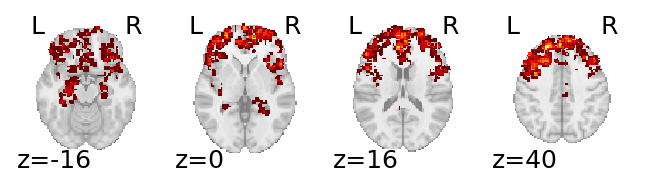

In [7]:
plot_selected_voxels()

Localize selected voxels at the region level

In [8]:
def plot_voxel_location(result_dict, filepath):
    plt.figure(figsize = (6, 4))
    result_labels, left_result, right_result = [], [], []
    for roi_label in result_dict.keys():
        result_labels.append(roi_label)
        left_result.append(np.mean(result_dict[roi_label].get("L", 0.)))
        right_result.append(np.mean(result_dict[roi_label].get("R", 0.)))
    # Plot top-10 ROIs with the highest voxel selection proportion considering both hemispheres
    left_order = np.argsort(left_result)[::-1]
    right_order = np.argsort(right_result)[::-1]
    result_order = find_overlap(left_order, right_order, overlap_num = 10)
    result_labels = np.array(result_labels)[result_order]
    
    y_locs = np.arange(1, len(result_labels)+1)
    plt.errorbar([np.mean(result_dict[roi_label]["L"]) for roi_label in result_labels], y_locs-0.15, 
                 xerr = [np.std(result_dict[roi_label]["L"]) for roi_label in result_labels],
                 fmt = 'o', color = 'r', capsize = 4, label = "left hemi")
    plt.errorbar([np.mean(result_dict[roi_label]["R"]) for roi_label in result_labels], y_locs+0.15, 
                 xerr = [np.std(result_dict[roi_label]["R"]) for roi_label in result_labels],
                 fmt = 'o', color = 'g', capsize = 4, label = "right hemi")
    plt.yticks(y_locs, [AAL3_label2name[roi_label] for roi_label in result_labels], fontsize = 16)
    plt.xticks(fontsize = 15)
    plt.xlabel("Voxel selection proportion", fontsize = 15)
    plt.gca().invert_yaxis()
    plt.legend(fontsize = 15)
    plt.tight_layout()
    plt.show()
    # plt.savefig(filepath, dpi = 300)
    # plt.close()

In [11]:
# Find out which regions are selected most frequently
def localize_selected_voxels():
    subs = glob.glob(os.path.join(PATHs["realtime"], "20*S*S*"))
    aal3_img, aal3_data, _, aal3_id2label, _ = load_aal3(os.path.join(PATHs["data"], "templates", "AAL3v1.nii"))
    result_dict = {}
    for sub in subs:
        roi_counts = {}
        voxel_coords = load_voi_file(sub, aal3_img)
        for coord in voxel_coords:
            vxl_label = aal3_id2label.get(aal3_data[coord[0], coord[1], coord[2]], None)
            if vxl_label is not None:
                roi_counts[vxl_label] = roi_counts.get(vxl_label, 0) + 1
        for roi_label, roi_count in roi_counts.items():
            region_name, hemi = roi_label[:-2], roi_label[-1]
            if region_name not in result_dict: result_dict[region_name] = {"L": [], "R": []}
            result_dict[region_name][hemi].append(roi_count / voxel_coords.shape[0])
    plot_voxel_location(result_dict, os.path.join(PATHs["result"], "figures", "voxel-density.png"))

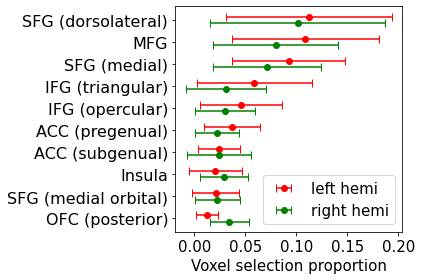

In [12]:
localize_selected_voxels()

#### 2. Group-level (dis)similarity analysis

In [13]:
def RDM_variability():
    subs_dir = os.path.join(PATHs["realtime"], "20*S*S*")
    subs = glob.glob(subs_dir)
    subs_corrs = []
    for sub in subs:
        base_patterns = np.loadtxt(os.path.join(sub, "TBV_Files_Template_10blocks/rtRSA_output/sel_base_patterns.tvals"))
        sub_corr = np.corrcoef(base_patterns.T)
        subs_corrs.append(sub_corr)
    subs_corrs = np.stack(subs_corrs)
    RDM_mean, RDM_low, RDM_high = compute_RDM_variability(subs_corrs)
    RDM_low[np.diag_indices_from(RDM_low)] = 0.
    RDM_high[np.diag_indices_from(RDM_high)] = 0.
    plot_RDM(RDM_mean, filepath = os.path.join(PATHs["result"], "figures", "avg_RDM.png"))
    plot_RDM(RDM_low, filepath = os.path.join(PATHs["result"], "figures", "low_RDM.png"))
    plot_RDM(RDM_high, filepath = os.path.join(PATHs["result"], "figures", "high_RDM.png"))

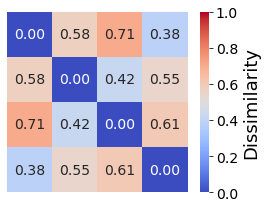

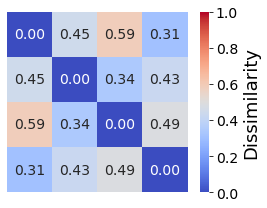

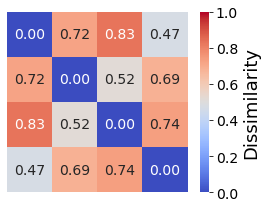

In [14]:
RDM_variability()